# Obesity Level Classification Using Artificial Intelligence Techniques

**Dataset:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition  
**Kaggle:** https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels  

## 1. Import Libraries

In [1]:
import os, sys, warnings, platform
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL']  = '3'
os.environ['CUDA_VISIBLE_DEVICES']  = '-1'   # CPU only — prevents crash

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mode

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, silhouette_score,
                                     davies_bouldin_score)
from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     VotingClassifier)
from sklearn.svm     import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow              import keras
from tensorflow.keras        import layers
from tensorflow.keras.utils  import to_categorical

# Limit GPU memory growth (safe on all machines)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully")
print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Platform   : {platform.system()} {platform.machine()}")


All libraries imported successfully
Python     : 3.10.20
TensorFlow : 2.12.0
NumPy      : 1.24.3
Pandas     : 2.3.3
Platform   : Darwin arm64


## 2. Data Loading and Pre-Processing

### 2.1 Load Dataset
> **Download from Kaggle:** https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels  



In [2]:
import pandas as pd

file_path = "/Users/manthan/Downloads/coursework/Applied AI/OBESITY LEVEL CLASSIFICATION USING ARTIFICIAL INTELLIGENCE TECHNIQUES /OBESITY-LEVEL-CLASSIFICATION-USING-ARTIFICIAL-INTELLIGENCE-TECHNIQUES-/Data /ObesityDataSet_raw_and_data_sinthetic.csv"

df = pd.read_csv(file_path)
print(df.head())

    Age  Gender  Height  Weight        CALC FAVC  FCVC  NCP  SCC SMOKE  CH2O  \
0  21.0  Female    1.62    64.0          no   no   2.0  3.0   no    no   2.0   
1  21.0  Female    1.52    56.0   Sometimes   no   3.0  3.0  yes   yes   3.0   
2  23.0    Male    1.80    77.0  Frequently   no   2.0  3.0   no    no   2.0   
3  27.0    Male    1.80    87.0  Frequently   no   3.0  3.0   no    no   2.0   
4  22.0    Male    1.78    89.8   Sometimes   no   2.0  1.0   no    no   2.0   

  family_history_with_overweight  FAF  TUE       CAEC                 MTRANS  \
0                            yes  0.0  1.0  Sometimes  Public_Transportation   
1                            yes  3.0  0.0  Sometimes  Public_Transportation   
2                            yes  2.0  1.0  Sometimes  Public_Transportation   
3                             no  2.0  0.0  Sometimes                Walking   
4                             no  0.0  0.0  Sometimes  Public_Transportation   

            NObeyesdad  
0        Norm

## 2.2 Exploratory Data Analysis

#### Data Types
The below chart identifies what type of data is recorded for each of these columns within the data set. For example, we will find out if each column is recorded by number (numeric), by name (categorical), or by whether the answer is true or false (boolean). 

#### Missing Values
- One way to validate the quality of the data is by checking for any missing values.
- If no missing cells are found → Data quality is acceptable.
  
#### Descriptive Statistics
- Before models are created, all existing records have to be processed first. In this section will show you some numerical columns using      statistics: -
- Mean → Average value  
- Std → Standard deviation (spread)  
- Min/Max → Range of values  
- Quartiles (25%, 50%, 75%) → Data distribution  


In [3]:
print("Data Types\n")

# Data Types
print("Data Types of Each Column:")
for col, dtype in df.dtypes.items():
    print(f"   - {col}: {dtype}")
print()

# Missing Values
print("Missing Values Check:")
missing = df.isnull().sum()

if missing.sum() == 0:
    print("   Great! No missing values found in the dataset.")
else:
    print("   Columns with missing values:")
    for col, val in missing[missing > 0].items():
        print(f"   - {col}: {val} missing values")
print()

# Descriptive Statistics
print("Summary Statistics:")
display(df.describe().round(3))

Data Types

Data Types of Each Column:
   - Age: float64
   - Gender: object
   - Height: float64
   - Weight: float64
   - CALC: object
   - FAVC: object
   - FCVC: float64
   - NCP: float64
   - SCC: object
   - SMOKE: object
   - CH2O: float64
   - family_history_with_overweight: object
   - FAF: float64
   - TUE: float64
   - CAEC: object
   - MTRANS: object
   - NObeyesdad: object

Missing Values Check:
   Great! No missing values found in the dataset.

Summary Statistics:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000,2111.000,2111.000,2111.000,2111.000,2111.000,2111.000,2111.000
mean,24.313,1.702,86.586,2.419,2.686,2.008,1.010,0.658
std,6.346,0.093,26.191,0.534,0.778,0.613,0.851,0.609
min,14.000,1.450,39.000,1.000,1.000,1.000,0.000,0.000
25%,19.947,1.630,65.473,2.000,2.659,1.585,0.125,0.000
50%,22.778,1.700,83.000,2.386,3.000,2.000,1.000,0.625
75%,26.000,1.768,107.431,3.000,3.000,2.477,1.667,1.000
max,61.000,1.980,173.000,3.000,4.000,3.000,3.000,2.000


## 2.3 Encode Categorical Features

#### Categorical Encoding

Categorical features were converted into numerical values using **Label Encoding**.

#### Encoded Columns
- Gender, family_history_with_overweight, FAVC  
- CAEC, SMOKE, SCC, CALC, MTRANS  

Each category is assigned a unique number (e.g., Male → 1, Female → 0).

#### Target Encoding
The target variable NObeyesdad (obesity level) was also encoded into numerical classes.

- `class_names`: Stores class labels  
- `n_classes`: Total number of classes  


In [4]:
categorical_cols = ['Gender','family_history_with_overweight','FAVC',
                    'CAEC','SMOKE','SCC','CALC','MTRANS']

le_dict    = {}
df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col]    = le
    print(f"  {col}: {list(le.classes_)}")

le_target                = LabelEncoder()
df_encoded['NObeyesdad'] = le_target.fit_transform(df_encoded['NObeyesdad'])
class_names              = le_target.classes_
n_classes                = len(class_names)
print(f"\nTarget classes ({n_classes}): {list(class_names)}")

  Gender: ['Female', 'Male']
  family_history_with_overweight: ['no', 'yes']
  FAVC: ['no', 'yes']
  CAEC: ['Always', 'Frequently', 'Sometimes', 'no']
  SMOKE: ['no', 'yes']
  SCC: ['no', 'yes']
  CALC: ['Always', 'Frequently', 'Sometimes', 'no']
  MTRANS: ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']

Target classes (7): ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


### 2.4 Outlier Detection, Scaling and Train/Test Split

####  Outlier Detection (IQR Method)
Outliers were identified using the **Interquartile Range (IQR)** method on numerical features:

- Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE  

Formula used:
- IQR = Q3 − Q1  
- Lower Bound = Q1 − 1.5 × IQR  
- Upper Bound = Q3 + 1.5 × IQR  

Values outside this range are considered outliers.

---

####  Feature & Target Split
- **X (Features):** All columns except `NObeyesdad`  
- **y (Target):** `NObeyesdad` (obesity level)

---

###  Feature Scaling
All features were standardized using **StandardScaler**:
- Mean = 0  
- Standard Deviation = 1  

This ensures all features contribute equally to the model.

---

###  Train-Test Split
The dataset was split into:
- **80% Training Data**
- **20% Testing Data**

Additional settings:
- `random_state = 42` (for reproducibility)  
- `stratify = y` (preserves class distribution)

---


In [5]:
numerical_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']

print("--- IQR Outlier Detection ---")
for col in numerical_cols:
    Q1      = df[col].quantile(0.25)
    Q3      = df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lo, hi  = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out   = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    print(f"  {col:8s}: Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  Outliers={n_out}")

X             = df_encoded.drop('NObeyesdad', axis=1)
y             = df_encoded['NObeyesdad']
feature_names = list(X.columns)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nStandardScaler applied to all features (mean=0, std=1)")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples  (80/20 split)")


--- IQR Outlier Detection ---
  Age     : Q1=19.95  Q3=26.00  IQR=6.05  Outliers=168
  Height  : Q1=1.63  Q3=1.77  IQR=0.14  Outliers=1
  Weight  : Q1=65.47  Q3=107.43  IQR=41.96  Outliers=1
  FCVC    : Q1=2.00  Q3=3.00  IQR=1.00  Outliers=0
  NCP     : Q1=2.66  Q3=3.00  IQR=0.34  Outliers=579
  CH2O    : Q1=1.58  Q3=2.48  IQR=0.89  Outliers=0
  FAF     : Q1=0.12  Q3=1.67  IQR=1.54  Outliers=0
  TUE     : Q1=0.00  Q3=1.00  IQR=1.00  Outliers=0

StandardScaler applied to all features (mean=0, std=1)
Train: 1688 samples  |  Test: 423 samples  (80/20 split)


## 3. Data Visualisation

A bar chart was created to show the distribution of obesity levels in the dataset.

- Displays the number of samples in each class  
- Uses a custom color palette for better visualization

- Data labels added on top of each bar  
- Figure saved as **fig1_class_distribution.png**


#### Figure 1 - Class Distrubution 


 VISUALIZATION: CLASS DISTRIBUTION

 Creating a bar chart to show how obesity levels are distributed in the dataset...
 Each bar represents the number of samples in a specific obesity category.
 Values are displayed on top of each bar for clarity.



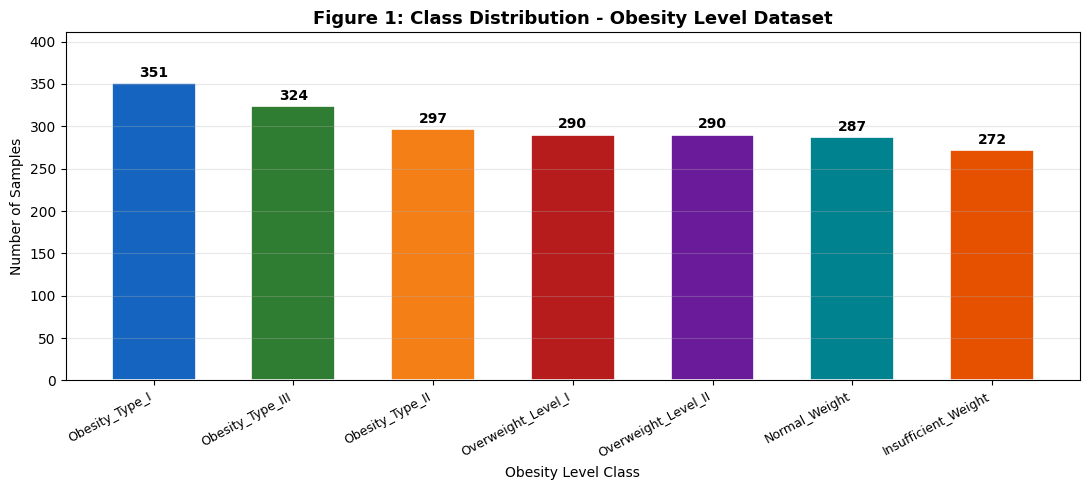

In [6]:
PALETTE = ['#1565C0','#2E7D32','#F57F17','#B71C1C','#6A1B9A','#00838F','#E65100']

print("\n VISUALIZATION: CLASS DISTRIBUTION\n")

print(" Creating a bar chart to show how obesity levels are distributed in the dataset...")
print(" Each bar represents the number of samples in a specific obesity category.")
print(" Values are displayed on top of each bar for clarity.\n")

# Plot
fig, ax = plt.subplots(figsize=(11,5))

cv = df['NObeyesdad'].value_counts()
bars = ax.bar(cv.index, cv.values, color=PALETTE, edgecolor='white', linewidth=1.2, width=0.6)

# Add labels on bars
for b, v in zip(bars, cv.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+4,
            str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titles and labels
ax.set_title('Figure 1: Class Distribution - Obesity Level Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Obesity Level Class')
ax.set_ylabel('Number of Samples')

ax.set_ylim(0, cv.max()+60)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=28, ha='right', fontsize=9)
plt.tight_layout()

# Save 
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Figure 2 - Correlation Heatmap


 VISUALIZATION: FEATURE CORRELATION HEATMAP

 Generating a heatmap to understand relationships between features...
 Correlation values range from -1 to +1:
   • +1 → Strong positive relationship
   • -1 → Strong negative relationship
   •  0 → No relationship



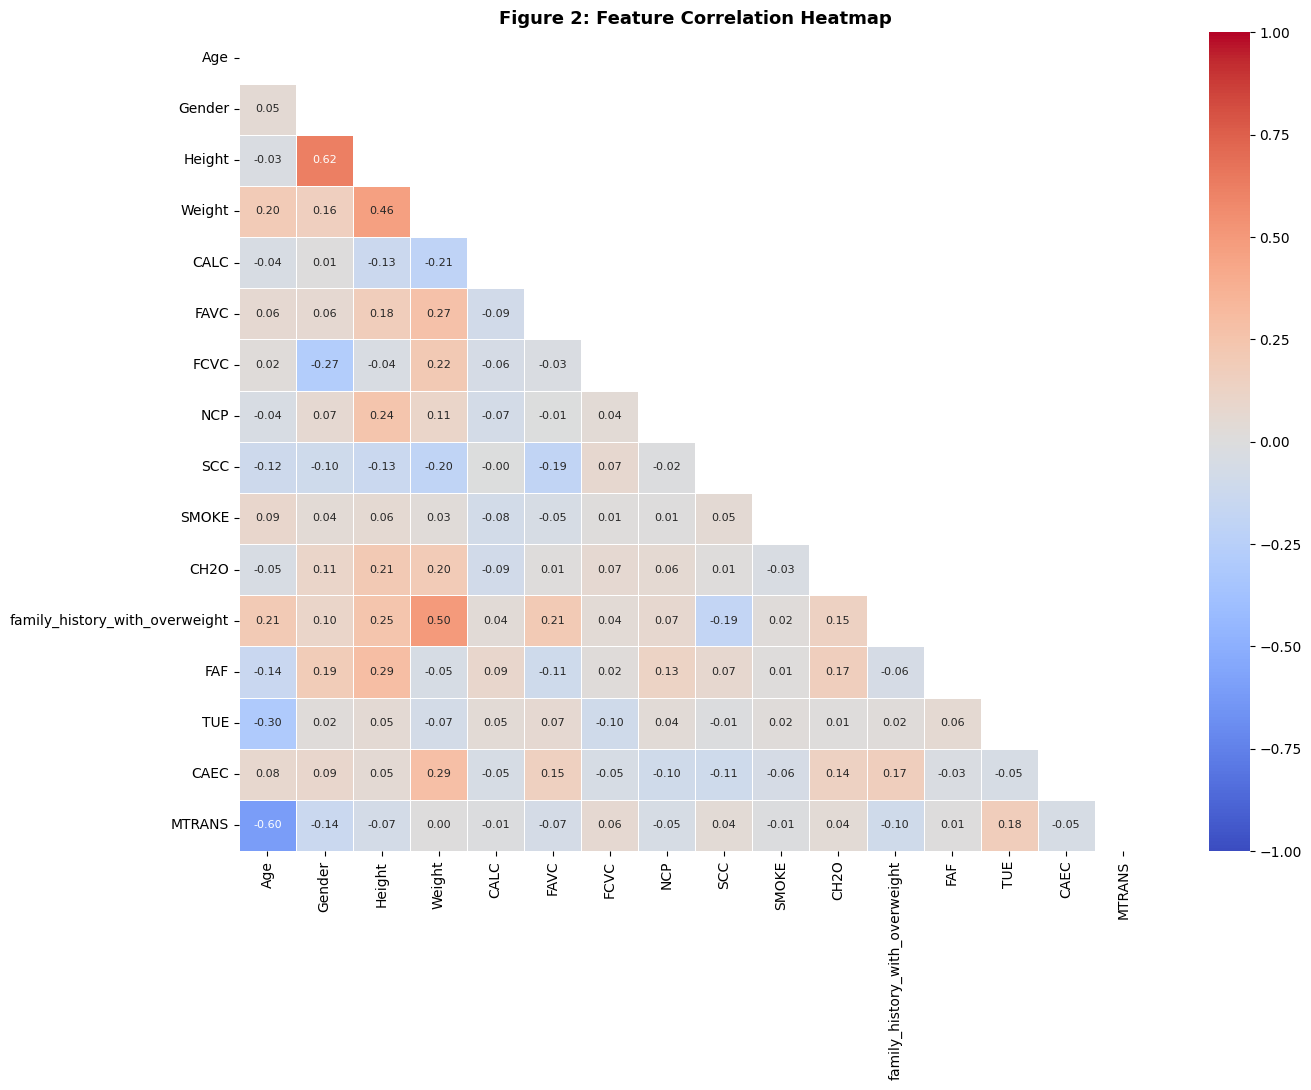

In [7]:
print("\n VISUALIZATION: FEATURE CORRELATION HEATMAP\n")

print(" Generating a heatmap to understand relationships between features...")
print(" Correlation values range from -1 to +1:")
print("   • +1 → Strong positive relationship")
print("   • -1 → Strong negative relationship")
print("   •  0 → No relationship\n")

# Create correlation matrix
corr = pd.DataFrame(X_scaled, columns=feature_names).corr()

# Mask upper triangle for cleaner visualization
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
fig, ax = plt.subplots(figsize=(14,11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size':8}, vmin=-1, vmax=1)

# Title
ax.set_title('Figure 2: Feature Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()

# Save and display
plt.savefig('fig2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


#### Figure 3 - Boxplots-outlier detection 


 VISUALIZATION: BOXPLOTS (OUTLIER DETECTION)

 Creating boxplots for each numerical feature in the dataset...
 These plots help identify the spread of data and detect outliers.
 The central line represents the median, and points outside the whiskers indicate potential outliers.



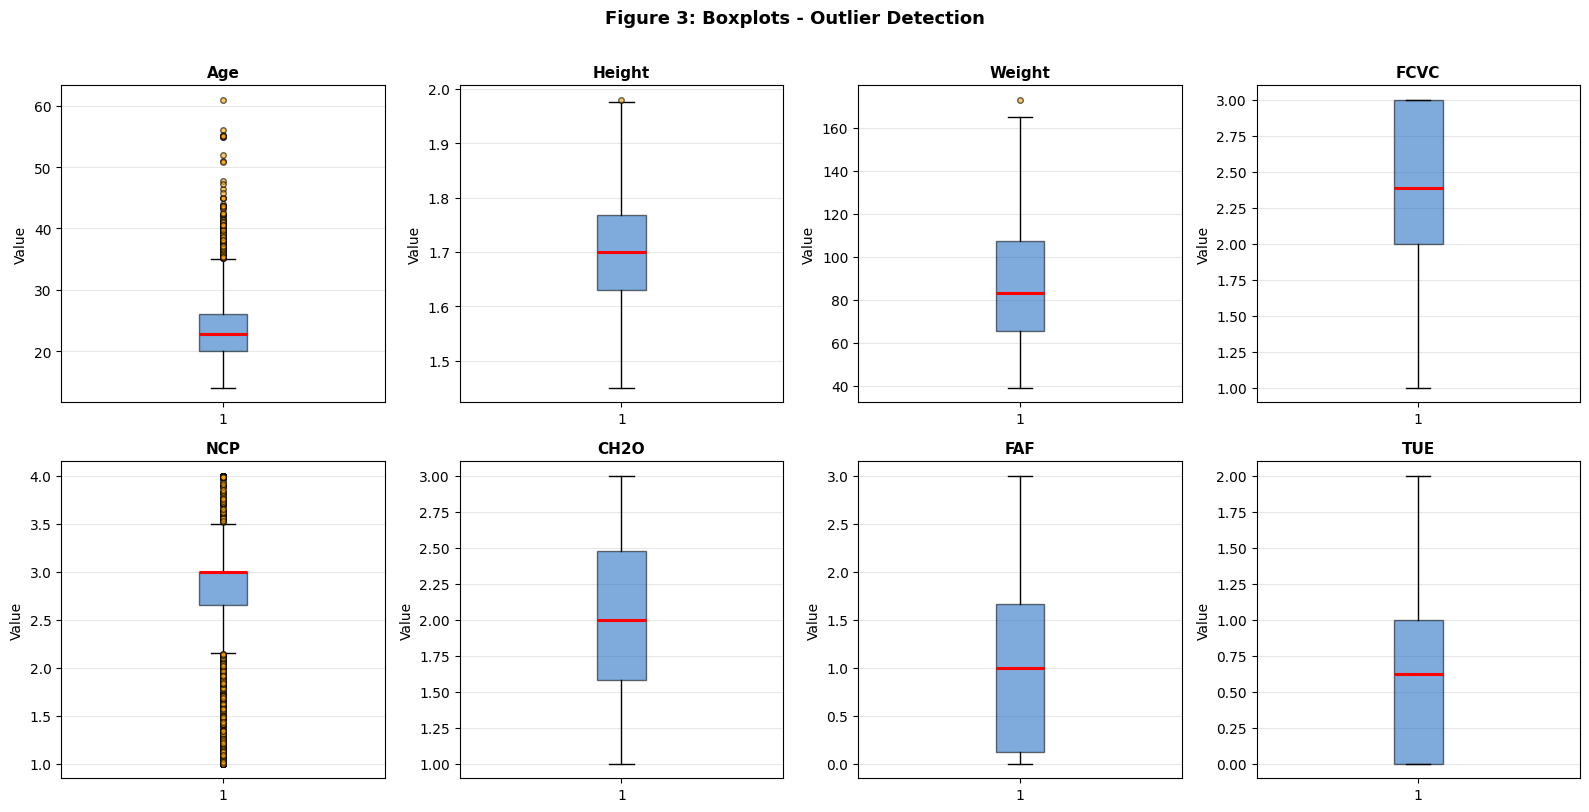

Saved: fig3_boxplots.png


In [8]:
print("\n VISUALIZATION: BOXPLOTS (OUTLIER DETECTION)\n")

print(" Creating boxplots for each numerical feature in the dataset...")
print(" These plots help identify the spread of data and detect outliers.")
print(" The central line represents the median, and points outside the whiskers indicate potential outliers.\n")

# Create a grid of subplots (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Loop through each numerical column and plot boxplot
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor='#1565C0', alpha=0.55),  # box color
        medianprops=dict(color='red', linewidth=2.2),    # median line
        flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.6)  # outliers
    )
    
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

# Overall title
plt.suptitle('Figure 3: Boxplots - Outlier Detection', fontsize=13, fontweight='bold', y=1.01)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('fig3_boxplots.png', dpi=150, bbox_inches='tight')

# Display plot
plt.show()

print("Saved: fig3_boxplots.png")

#### Figure 4 - Feature Distributions


 VISUALIZATION: FEATURE DISTRIBUTIONS

 Creating histograms for each numerical feature in the dataset...
 These plots show how the values of each feature are distributed.
 The x-axis represents the value range, while the y-axis shows the frequency of observations.



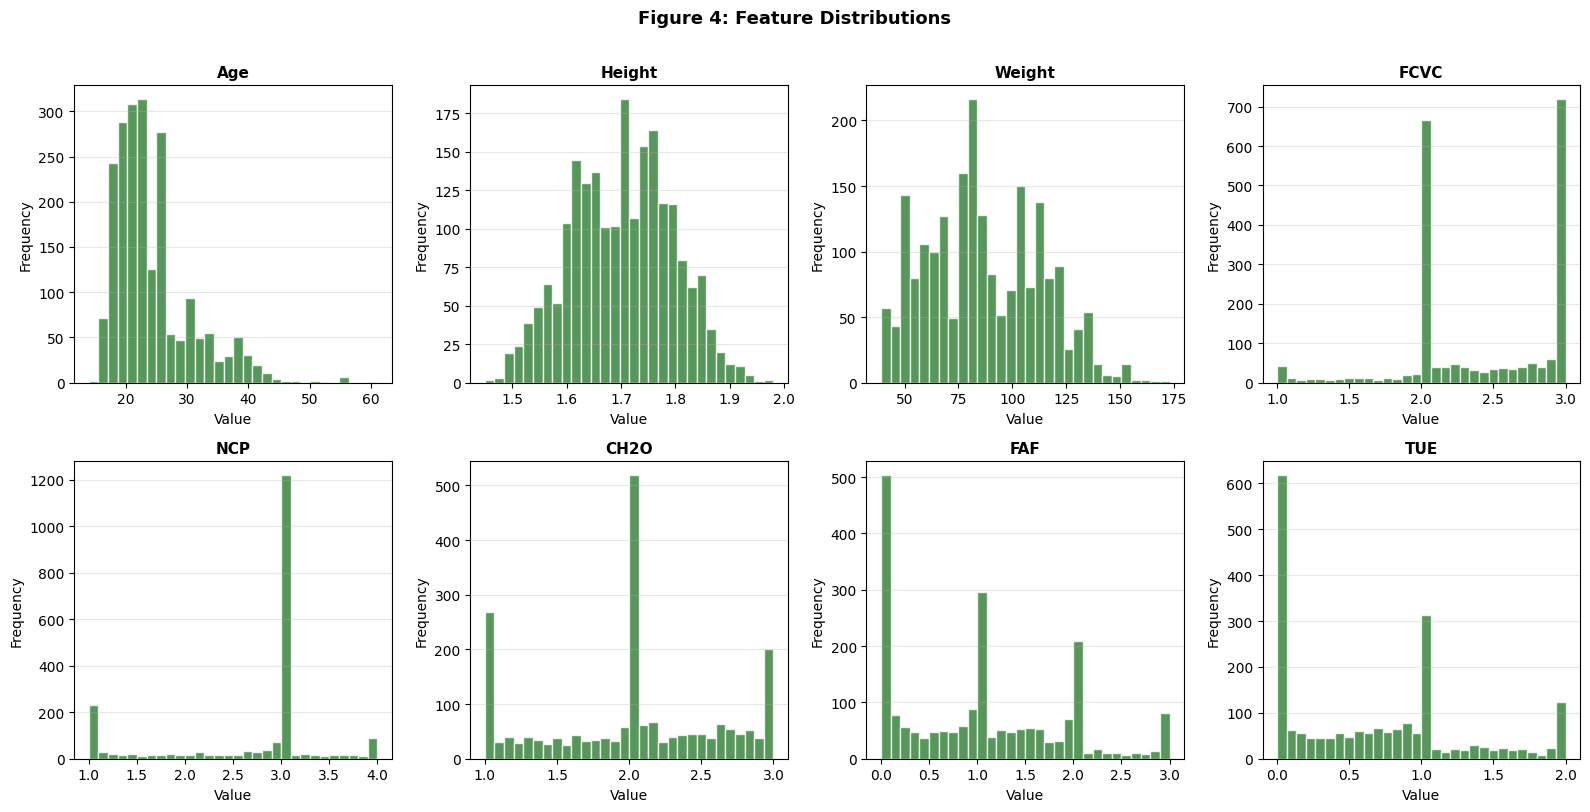

Saved: fig4_distributions.png


In [9]:
print("\n VISUALIZATION: FEATURE DISTRIBUTIONS\n")

print(" Creating histograms for each numerical feature in the dataset...")
print(" These plots show how the values of each feature are distributed.")
print(" The x-axis represents the value range, while the y-axis shows the frequency of observations.\n")

# Create a grid of subplots (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Loop through each numerical column and plot histogram
for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df[col],
        bins=30,
        color='#2E7D32',       # green color for bars
        edgecolor='white',
        alpha=0.8
    )
    
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

# Overall title
plt.suptitle('Figure 4: Feature Distributions', fontsize=13, fontweight='bold', y=1.01)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('fig4_distributions.png', dpi=150, bbox_inches='tight')

# Display plot
plt.show()

print("Saved: fig4_distributions.png")

#### Figure 5 - Weight vs Height


 VISUALIZATION: HEIGHT vs WEIGHT BY OBESITY CLASS

 Creating a scatter plot to analyze the relationship between height and weight...
 Each point represents an individual in the dataset.
 Different colors indicate different obesity categories.



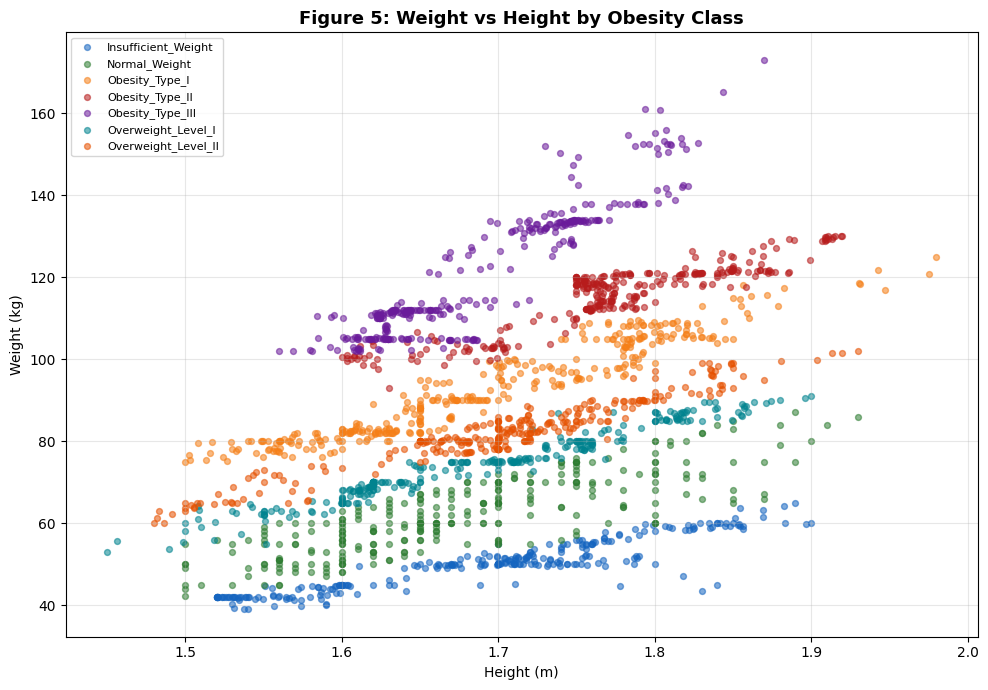

Saved: fig5_weight_vs_height.png


In [10]:
print("\n VISUALIZATION: HEIGHT vs WEIGHT BY OBESITY CLASS\n")

print(" Creating a scatter plot to analyze the relationship between height and weight...")
print(" Each point represents an individual in the dataset.")
print(" Different colors indicate different obesity categories.\n")

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Plot scatter points for each class
for i, cls in enumerate(class_names):
    m = df['NObeyesdad'] == cls
    
    ax.scatter(
        df.loc[m, 'Height'],
        df.loc[m, 'Weight'],
        c=PALETTE[i],
        label=cls,
        alpha=0.55,
        s=18
    )

# Labels and title
ax.set_xlabel('Height (m)')
ax.set_ylabel('Weight (kg)')
ax.set_title('Figure 5: Weight vs Height by Obesity Class', fontsize=13, fontweight='bold')

# Legend and grid
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('fig5_weight_vs_height.png', dpi=150, bbox_inches='tight')

# Display plot
plt.show()

print("Saved: fig5_weight_vs_height.png")

## 4. Task 1 - MLP Classifier (Keras / TensorFlow)

#### MLP Model (4 Hidden Layers)

- Input: Feature vector from the processed dataset
- Output: 7-class classification using Softmax

#### Architecture:
- Hidden Layer 1: 15 neurons (ReLU) + BatchNorm + Dropout(0.2)
- Hidden Layer 2: 25 neurons (ReLU) + BatchNorm + Dropout(0.2)
- Hidden Layer 3: 25 neurons (ReLU) + BatchNorm + Dropout(0.2)
- Hidden Layer 4: 20 neurons (ReLU) + BatchNorm

#### Output Layer:
- Dense layer with 7 neurons
- Activation: Softmax

#### Training Setup:
- Optimizer: Adam with learning rate = 0.001
- Loss Function: Categorical Crossentropy
- Evaluation Metric: Accuracy

#### Preprocessing:
- Class labels converted using One-Hot Encoding

In [11]:
# Convert the target labels into one-hot encoded vectors.
# This format is required for multi-class classification using softmax output.
# Example:
# Class 3 becomes [0, 0, 0, 1, 0, 0, 0]
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test, num_classes=n_classes)


# Build the Multi-Layer Perceptron (MLP) model.
# The network contains 4 hidden layers as required in the coursework brief.
mlp_model = keras.Sequential([

    # Input layer:
    # Accepts one row of feature values at a time.
    layers.Input(shape=(X_train.shape[1],)),


    # Hidden Layer 1:
    # Uses 15 neurons to learn initial feature patterns.
    layers.Dense(15, activation='relu', name='hidden_layer_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Hidden Layer 2:
    # Expands the learning capacity to capture more complex relationships.
    layers.Dense(25, activation='relu', name='hidden_layer_2'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Hidden Layer 3:
    # Another dense layer with 25 neurons to further refine feature learning.
    layers.Dense(25, activation='relu', name='hidden_layer_3'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Hidden Layer 4:
    # Final hidden layer with 20 neurons before classification output.
    layers.Dense(20, activation='relu', name='hidden_layer_4'),
    layers.BatchNormalization(),


    # Output layer:
    # Contains one neuron for each obesity category.
    # Softmax converts outputs into probability values.
    layers.Dense(n_classes, activation='softmax', name='output_layer')

], name='MLP_4_Hidden_Layers')


# Compile the model.
# Adam optimizer is used because it provides efficient and adaptive learning.
# Categorical crossentropy is appropriate for multi-class classification problems.
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Display the complete model architecture and parameter summary.
mlp_model.summary()

Metal device set to: Apple M5


Model: "MLP_4_Hidden_Layers"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_layer_1 (Dense)      (None, 15)                255       
                                                                 
 batch_normalization (BatchN  (None, 15)               60        
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 15)                0         
                                                                 
 hidden_layer_2 (Dense)      (None, 25)                400       
                                                                 
 batch_normalization_1 (Batc  (None, 25)               100       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 25)        

In [12]:
# Create an Early Stopping callback
# This will monitor the validation loss during training
# If the validation loss does not improve for 10 consecutive epochs,
# the training will stop automatically to prevent overfitting

early_mlp = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

print("Training MLP... please wait...")
mlp_history = mlp_model.fit(
    X_train, y_train_cat,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=[early_mlp],
    verbose=1
)


Training MLP... please wait...
Epoch 1/100
43/43 [==============================] - 2s 31ms/step - loss: 2.1671 - accuracy: 0.1970 - val_loss: 1.9104 - val_accuracy: 0.2426
Epoch 2/100
43/43 [==============================] - 1s 21ms/step - loss: 1.9024 - accuracy: 0.2956 - val_loss: 1.8067 - val_accuracy: 0.3787
Epoch 3/100
43/43 [==============================] - 1s 24ms/step - loss: 1.7556 - accuracy: 0.3637 - val_loss: 1.6786 - val_accuracy: 0.4231
Epoch 4/100
43/43 [==============================] - 1s 17ms/step - loss: 1.6354 - accuracy: 0.3719 - val_loss: 1.5422 - val_accuracy: 0.4556
Epoch 5/100
43/43 [==============================] - 1s 24ms/step - loss: 1.5638 - accuracy: 0.4200 - val_loss: 1.4250 - val_accuracy: 0.4852
Epoch 6/100
43/43 [==============================] - 1s 24ms/step - loss: 1.4750 - accuracy: 0.4393 - val_loss: 1.3370 - val_accuracy: 0.4852
Epoch 7/100
43/43 [==============================] - 1s 25ms/step - loss: 1.4358 - accuracy: 0.4452 - val_loss: 1.271

In [21]:
# Make predictions on the test data
# The model outputs probabilities for each class
mlp_pred = np.argmax(mlp_model.predict(X_test, verbose=0), axis=1)

# Calculate the accuracy of the model on test data
mlp_accuracy = accuracy_score(y_test, mlp_pred)

# Print the test accuracy in percentage format
print(f"MLP Test Accuracy : {mlp_accuracy * 100:.2f}%")

# Print how many epochs the model actually trained for
# (useful because early stopping may stop training early)
print(f"Epochs trained    : {len(mlp_history.history['accuracy'])}")

print()

# Print a detailed classification report
# This includes precision, recall, f1-score for each class
print("MLP Classification Report:")
print(classification_report(y_test, mlp_pred, target_names=class_names))

MLP Test Accuracy : 94.09%
Epochs trained    : 98

MLP Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.96      0.97        54
      Normal_Weight       0.89      0.88      0.89        58
     Obesity_Type_I       0.94      0.97      0.96        70
    Obesity_Type_II       0.97      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.85      0.90      0.87        58
Overweight_Level_II       0.95      0.90      0.92        58

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



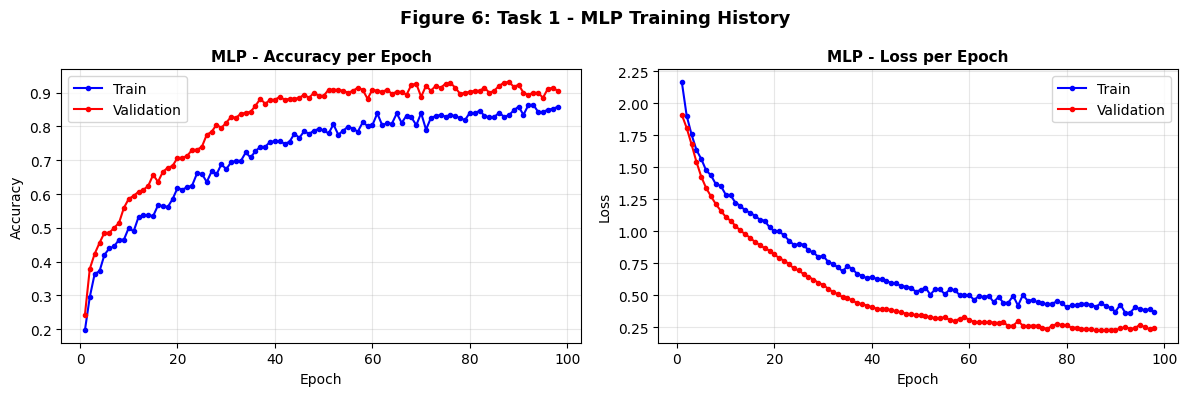

Saved: fig6_mlp_curves.png


In [22]:
# Create a figure with two subplots placed side by side
# One will show accuracy, the other will show loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Create a range for epochs (1 to total number of epochs trained)
ep = range(1, len(mlp_history.history['accuracy']) + 1)

# -------------------------------
# Plot Accuracy Graph
# -------------------------------

# Plot training accuracy
ax1.plot(ep, mlp_history.history['accuracy'], 'b-o', ms=3, label='Train')

# Plot validation accuracy
ax1.plot(ep, mlp_history.history['val_accuracy'], 'r-o', ms=3, label='Validation')

# Set title and labels
ax1.set_title('MLP - Accuracy per Epoch', fontsize=11, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

# Show legend and grid
ax1.legend()
ax1.grid(alpha=0.3)


# -------------------------------
# Plot Loss Graph
# -------------------------------

# Plot training loss
ax2.plot(ep, mlp_history.history['loss'], 'b-o', ms=3, label='Train')

# Plot validation loss
ax2.plot(ep, mlp_history.history['val_loss'], 'r-o', ms=3, label='Validation')

# Set title and labels
ax2.set_title('MLP - Loss per Epoch', fontsize=11, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

# Show legend and grid
ax2.legend()
ax2.grid(alpha=0.3)


# Add an overall title for the entire figure
plt.suptitle('Figure 6: Task 1 - MLP Training History', fontsize=13, fontweight='bold')

# Adjust layout so elements don’t overlap
plt.tight_layout()

# Save the figure as an image file
plt.savefig('fig6_mlp_curves.png', dpi=150, bbox_inches='tight')

# Display the plots
plt.show()

# Confirm that the file has been saved
print("Saved: fig6_mlp_curves.png")

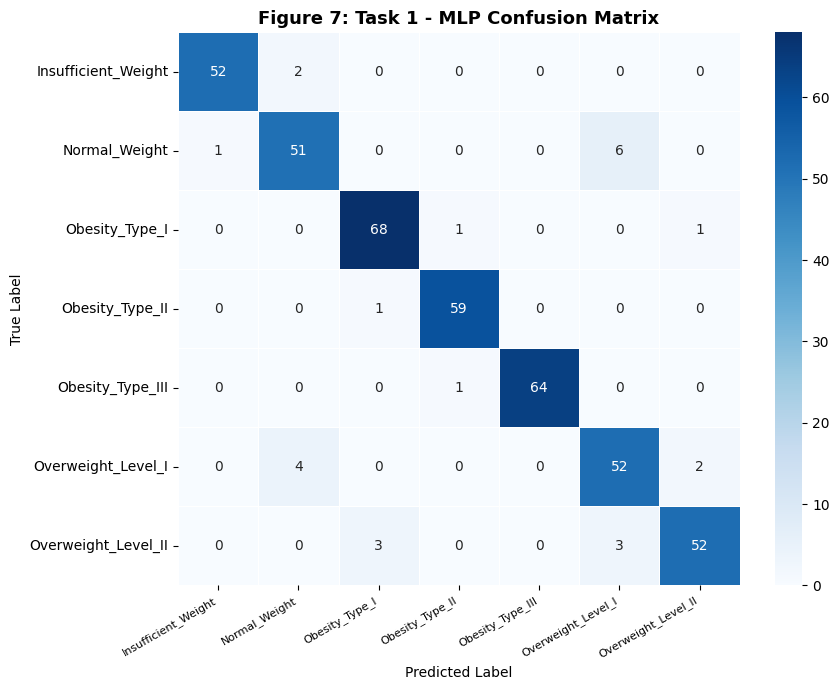

Saved: fig7_mlp_confusion.png


In [23]:
# Create a figure for the confusion matrix
# Set the size to make it clearly visible
fig, ax = plt.subplots(figsize=(9, 7))

# Generate and display the confusion matrix as a heatmap

sns.heatmap(
    confusion_matrix(y_test, mlp_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,   # Labels for predicted classes
    yticklabels=class_names,   # Labels for actual classes
    ax=ax,
    linewidths=0.5             # Adds grid lines between cells
)

# Set the title and axis labels
ax.set_title('Figure 7: Task 1 - MLP Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=8)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the confusion matrix as an image file
plt.savefig('fig7_mlp_confusion.png', dpi=150, bbox_inches='tight')

# Display the plot
plt.show()

# Print confirmation message
print("Saved: fig7_mlp_confusion.png")

## 5. Task 2 — Ensemble Model (scikit-learn)
**VotingClassifier (soft voting):**
- Random Forest — weight 3
- Gradient Boosting — weight 2
- SVM RBF kernel — weight 1


In [24]:
# Random Forest:
# Uses many decision trees and combines their outputs.
# Good at reducing overfitting and handling complex patterns.
rf_clf = RandomForestClassifier(
    n_estimators=200,          
    max_depth=15,              
    min_samples_split=5,      
    min_samples_leaf=2,        
    max_features='sqrt',       
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1                  
)

# Builds trees sequentially, where each new tree corrects
# errors made by previous trees.
gb_clf = GradientBoostingClassifier(
    n_estimators=150,          
    learning_rate=0.1,         
    max_depth=5,              
    subsample=0.8,             
    max_features='sqrt',       
    random_state=42
)

# Support Vector Machine (SVM):
# Finds the best boundary between classes.
# RBF kernel helps capture non-linear relationships.
svm_clf = SVC(
    kernel='rbf',
    C=10,                      
    gamma='scale',             
    probability=True,          
    random_state=42
)

# -------------------------
# Create Ensemble Model
# -------------------------
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('gb', gb_clf),
        ('svm', svm_clf)
    ],
    voting='soft',
    weights=[3, 2, 1]          
)

# -------------------------
# Train the Ensemble
# -------------------------

print("Training Ensemble Model (RF + GB + SVM)...")
print("Please wait, training may take 1-2 minutes.\n")

ensemble.fit(X_train, y_train)

# -------------------------
# Evaluate Performance
# -------------------------

# Predict on test data
ens_pred = ensemble.predict(X_test)

# Calculate accuracy
ens_accuracy = accuracy_score(y_test, ens_pred)

print(f"Ensemble Test Accuracy: {ens_accuracy * 100:.2f}%\n")

# Detailed classification report
print("Ensemble Classification Report:")
print(classification_report(
    y_test,
    ens_pred,
    target_names=class_names
))

Training Ensemble Model (RF + GB + SVM)...
Please wait, training may take 1-2 minutes.

Ensemble Test Accuracy: 95.74%

Ensemble Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.91      0.95        54
      Normal_Weight       0.83      0.98      0.90        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.88      0.93        58
Overweight_Level_II       0.97      0.98      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



Random Forest Standalone Accuracy: 95.74%


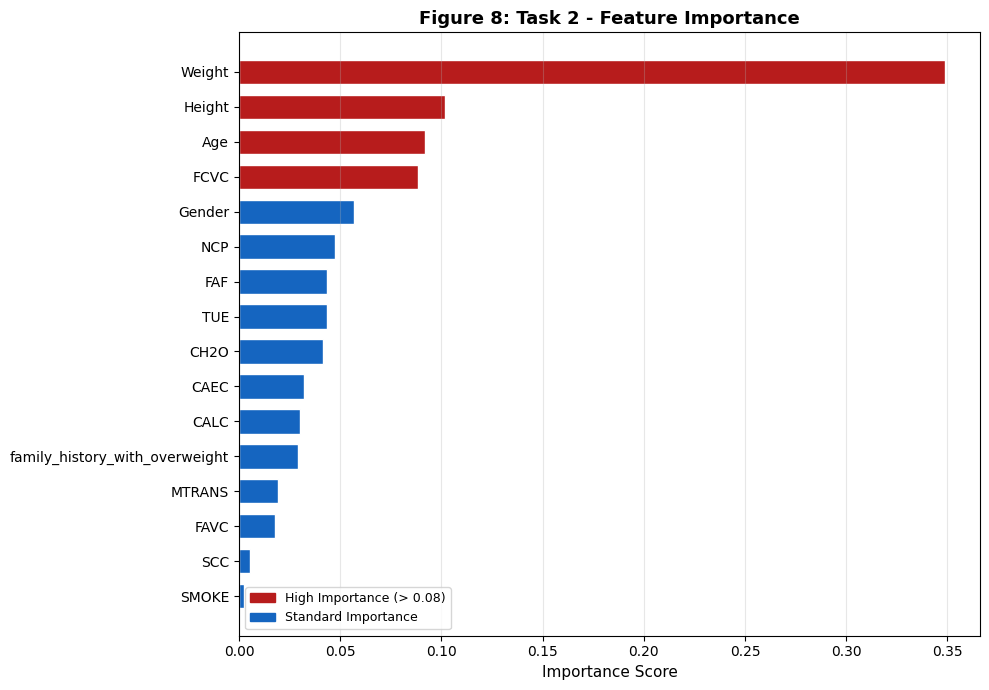

Feature importance figure saved as: fig8_feature_importance.png


In [25]:
# -----------------------------------------
# Train Random Forest Model Separately
# -----------------------------------------

# A standalone Random Forest model is trained
# to analyze feature importance more clearly.
rf_solo = RandomForestClassifier(
    n_estimators=200,      
    max_depth=15,          
    random_state=42,
    n_jobs=-1              
)

# Train the model
rf_solo.fit(X_train, y_train)

# Evaluate model performance
rf_accuracy = accuracy_score(y_test, rf_solo.predict(X_test))

print(f"Random Forest Standalone Accuracy: {rf_accuracy * 100:.2f}%")

# -----------------------------------------
# Extract Feature Importance Scores
# -----------------------------------------

# Feature importance tells us how useful
# each feature is for prediction.
importance_scores = rf_solo.feature_importances_

# Sort features from lowest to highest importance
sorted_idx = np.argsort(importance_scores)

# -----------------------------------------
#  Bar Colors
# -----------------------------------------

# Features with importance > 0.08 are highlighted in red,
# while the remaining features are shown in blue.
bar_colors = [
    '#B71C1C' if importance_scores[i] > 0.08 else '#1565C0'
    for i in sorted_idx
]

# -----------------------------------------
# Plot Feature Importance Graph
# -----------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

# Horizontal bar chart
ax.barh(
    [feature_names[i] for i in sorted_idx],
    importance_scores[sorted_idx],
    color=bar_colors,
    edgecolor='white',
    height=0.7
)

# Axis labels and title
ax.set_xlabel('Importance Score', fontsize=11)

ax.set_title(
    'Figure 8: Task 2 - Feature Importance',
    fontsize=13,
    fontweight='bold'
)

# Add grid lines for readability
ax.grid(axis='x', alpha=0.3)

# -----------------------------------------
# Add Legend
# -----------------------------------------

legend_items = [
    mpatches.Patch(color='#B71C1C', label='High Importance (> 0.08)'),
    mpatches.Patch(color='#1565C0', label='Standard Importance')
]

ax.legend(handles=legend_items, fontsize=9)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig(
    'fig8_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

# Display the plot
plt.show()

print("Feature importance figure saved as: fig8_feature_importance.png")

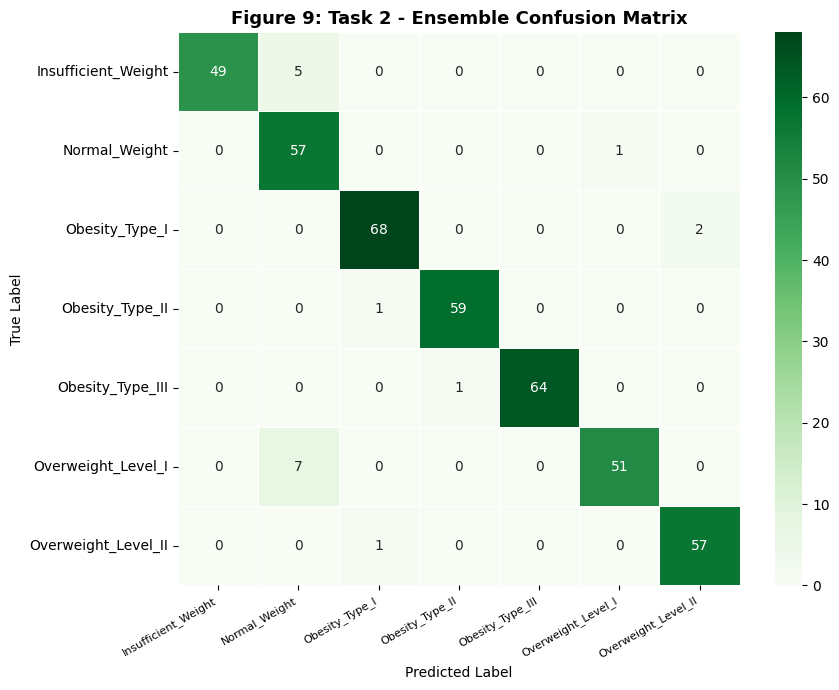

Confusion matrix figure saved as: fig9_ensemble_confusion.png


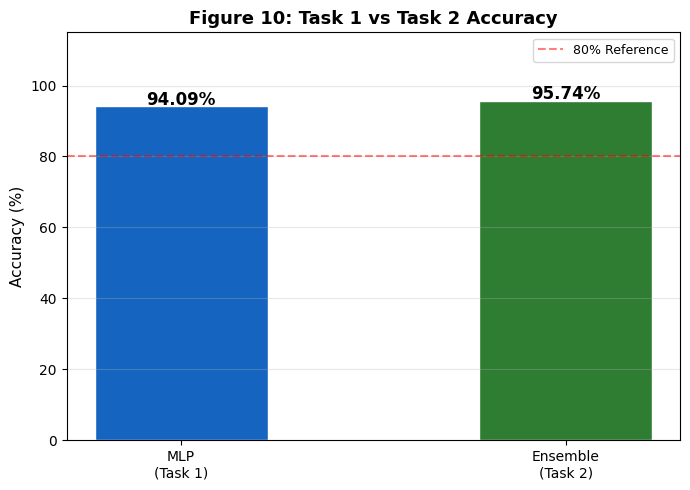

Accuracy comparison figure saved as: fig10_task1_vs_task2.png


In [26]:
# --------------------
# Confusion Matrix
# --------------------

# A confusion matrix helps visualize how well
# the ensemble model classified each category.

fig, ax = plt.subplots(figsize=(9, 7))

# Generate confusion matrix
cm = confusion_matrix(y_test, ens_pred)

# Create heatmap visualization
sns.heatmap(
    cm,
    annot=True,                 
    fmt='d',                    
    cmap='Greens',              
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5
)

# Add title and axis labels
ax.set_title(
    'Figure 9: Task 2 - Ensemble Confusion Matrix',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha='right', fontsize=8)

# Adjust spacing
plt.tight_layout()

# Save figure
plt.savefig(
    'fig9_ensemble_confusion.png',
    dpi=150,
    bbox_inches='tight'
)

# Display plot
plt.show()

print("Confusion matrix figure saved as: fig9_ensemble_confusion.png")


# -----------------------------------------
# Figure 10 - Task 1 vs Task 2 Accuracy
# -----------------------------------------

# Compare the performance of:
# 1. MLP model from Task 1
# 2. Ensemble model from Task 2

fig, ax = plt.subplots(figsize=(7, 5))

# Model names and accuracy values
model_names = ['MLP\n(Task 1)', 'Ensemble\n(Task 2)']
accuracy_values = [mlp_accuracy * 100, ens_accuracy * 100]

# Create bar chart
bars = ax.bar(
    model_names,
    accuracy_values,
    color=['#1565C0', '#2E7D32'],
    edgecolor='white',
    width=0.45
)

# Add accuracy labels above bars
for bar, accuracy in zip(bars, accuracy_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{accuracy:.2f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Axis settings
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=11)

# Chart title
ax.set_title(
    'Figure 10: Task 1 vs Task 2 Accuracy',
    fontsize=13,
    fontweight='bold'
)

# Reference accuracy line
ax.axhline(
    80,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='80% Reference'
)

# Add legend and grid
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    'fig10_task1_vs_task2.png',
    dpi=150,
    bbox_inches='tight'
)

# Display chart
plt.show()

print("Accuracy comparison figure saved as: fig10_task1_vs_task2.png")

## 6. Task 3 — Deep CNN with 4 Convolutional Layers (Keras / TensorFlow)

**Input reshape:** 16 features → (16, 1) for Conv1D  
**4 Conv Blocks:** 32 → 64 → 128 → 64 filters

In [27]:
# Store the total number of input features from the dataset.
n_feat = X_train.shape[1]


# Reshape the training and testing data for CNN input.
# Conv1D layers expect data in the format:
# (samples, timesteps/features, channels)
X_train_cnn = X_train.reshape(X_train.shape[0], n_feat, 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], n_feat, 1)


# Display the reshaped training data shape.
print(f"CNN input shape: {X_train_cnn.shape}")


# Build the Deep CNN model.
# This model contains 4 convolutional blocks for feature extraction.
cnn_model = keras.Sequential([

    # Convolution Block 1:
    # Learns simple local feature patterns from the input sequence.
    layers.Conv1D(
        32,
        3,
        activation='relu',
        padding='same',
        input_shape=(n_feat, 1),
        name='conv1'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2, padding='same'),


    # Convolution Block 2:
    # Increases the number of filters to learn more complex patterns.
    layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same',
        name='conv2'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2, padding='same'),


    # Convolution Block 3:
    # Uses 128 filters to capture higher-level feature representations.
    layers.Conv1D(
        128,
        3,
        activation='relu',
        padding='same',
        name='conv3'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2, padding='same'),


    # Convolution Block 4:
    # Final convolution layer used to refine extracted features.
    layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same',
        name='conv4'
    ),
    layers.BatchNormalization(),


    # Classification Head:
    # Converts extracted feature maps into class predictions.
    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),


    # Output layer:
    # Produces probability values for all obesity classes.
    layers.Dense(n_classes, activation='softmax', name='output')

], name='Deep_CNN_4_ConvLayers')


# Compile the CNN model.
# Adam optimizer is used for adaptive learning.
# Categorical crossentropy is used for multi-class classification.
cnn_model.compile(

    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)


# Display the complete CNN architecture and parameter summary.
cnn_model.summary()


CNN input shape: (1688, 16, 1)
Model: "Deep_CNN_4_ConvLayers"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv1D)              (None, 16, 32)            128       
                                                                 
 batch_normalization_8 (Batc  (None, 16, 32)           128       
 hNormalization)                                                 
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 8, 32)            0         
 1D)                                                             
                                                                 
 conv2 (Conv1D)              (None, 8, 64)             6208      
                                                                 
 batch_normalization_9 (Batc  (None, 8, 64)            256       
 hNormalization)                                                 
              

In [28]:
early_cnn = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=12, restore_best_weights=True, verbose=0)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

print("Training CNN... please wait...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=[early_cnn, reduce_lr],
    verbose=1
)


Training CNN... please wait...
Epoch 1/100
43/43 [==============================] - 2s 21ms/step - loss: 1.5996 - accuracy: 0.3889 - val_loss: 1.8921 - val_accuracy: 0.2278 - lr: 0.0010
Epoch 2/100
43/43 [==============================] - 1s 13ms/step - loss: 0.9577 - accuracy: 0.6630 - val_loss: 1.8176 - val_accuracy: 0.2189 - lr: 0.0010
Epoch 3/100
43/43 [==============================] - 1s 13ms/step - loss: 0.7017 - accuracy: 0.7526 - val_loss: 1.7403 - val_accuracy: 0.2544 - lr: 0.0010
Epoch 4/100
43/43 [==============================] - 1s 13ms/step - loss: 0.5385 - accuracy: 0.8126 - val_loss: 1.4497 - val_accuracy: 0.4379 - lr: 0.0010
Epoch 5/100
43/43 [==============================] - 1s 13ms/step - loss: 0.4342 - accuracy: 0.8533 - val_loss: 1.3312 - val_accuracy: 0.4556 - lr: 0.0010
Epoch 6/100
43/43 [==============================] - 1s 13ms/step - loss: 0.3136 - accuracy: 0.8963 - val_loss: 0.7771 - val_accuracy: 0.7456 - lr: 0.0010
Epoch 7/100
43/43 [====================

In [29]:
cnn_pred     = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)
cnn_accuracy = accuracy_score(y_test, cnn_pred)

print(f"CNN Test Accuracy : {cnn_accuracy*100:.2f}%")
print(f"Epochs trained    : {len(cnn_history.history['accuracy'])}")
print()
print("CNN Classification Report:")
print(classification_report(y_test, cnn_pred, target_names=class_names))

CNN Test Accuracy : 88.18%
Epochs trained    : 30

CNN Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.91      0.91        54
      Normal_Weight       0.74      0.74      0.74        58
     Obesity_Type_I       0.89      0.93      0.91        70
    Obesity_Type_II       0.95      0.93      0.94        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.80      0.81      0.80        58
Overweight_Level_II       0.89      0.84      0.87        58

           accuracy                           0.88       423
          macro avg       0.88      0.88      0.88       423
       weighted avg       0.88      0.88      0.88       423



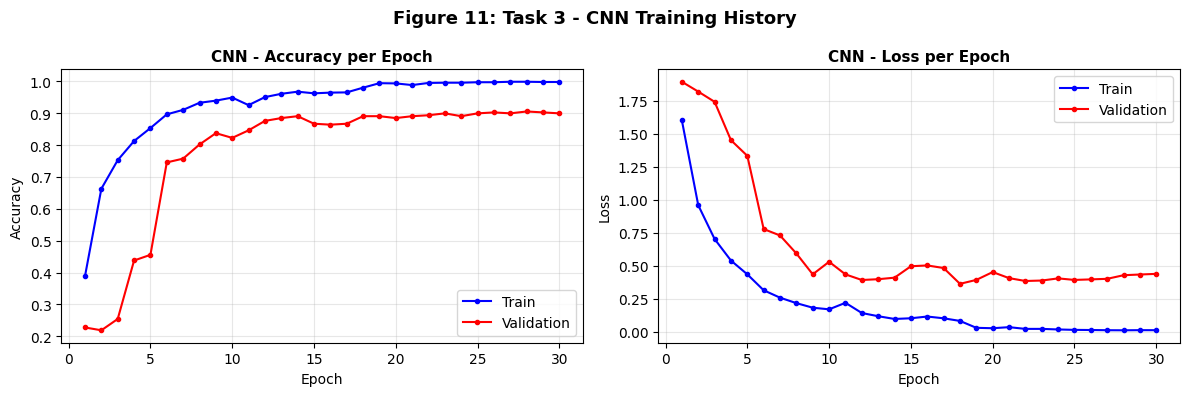

Saved: fig11_cnn_curves.png


In [30]:
# Figure 11 - CNN Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ec = range(1, len(cnn_history.history['accuracy'])+1)
ax1.plot(ec, cnn_history.history['accuracy'],     'b-o', ms=3, label='Train')
ax1.plot(ec, cnn_history.history['val_accuracy'], 'r-o', ms=3, label='Validation')
ax1.set_title('CNN - Accuracy per Epoch', fontsize=11, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ec, cnn_history.history['loss'],     'b-o', ms=3, label='Train')
ax2.plot(ec, cnn_history.history['val_loss'], 'r-o', ms=3, label='Validation')
ax2.set_title('CNN - Loss per Epoch', fontsize=11, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Figure 11: Task 3 - CNN Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig11_cnn_curves.png")

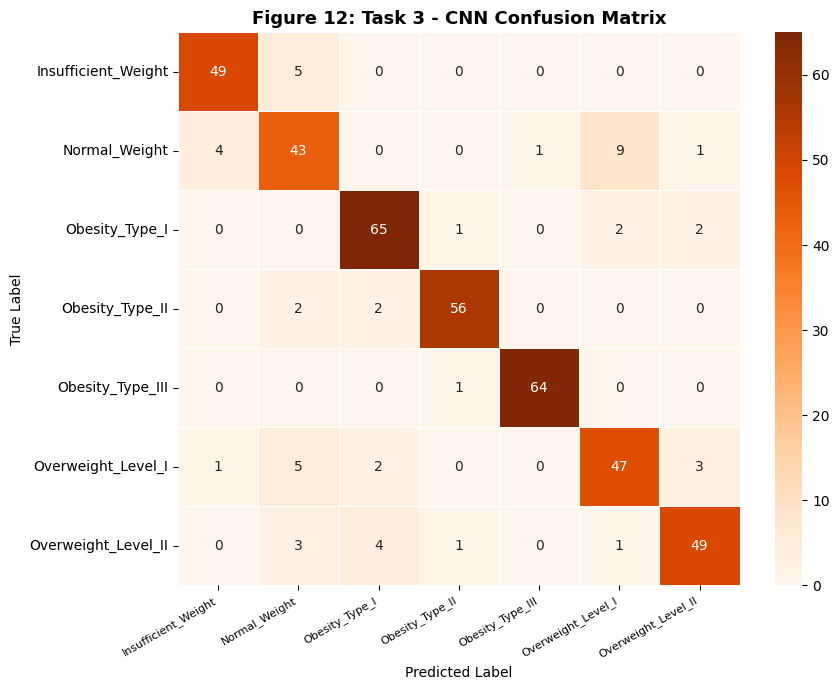

Saved: fig12_cnn_confusion.png


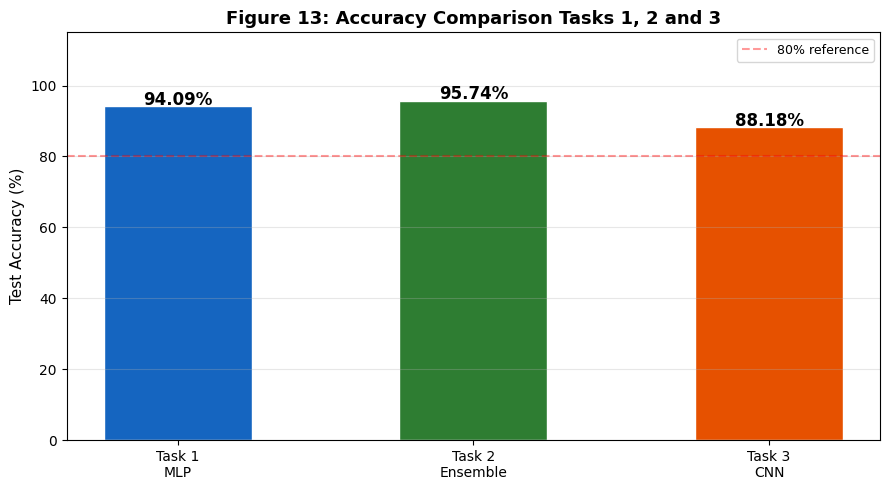

Saved: fig13_all_tasks_comparison.png

  
   Model                      Accuracy 
  
   Task 1: MLP (4 layers)     94.09%  
   Task 2: Ensemble            95.74%  
  Task 3: Deep CNN            88.18%  
  


In [31]:
# ============================
# Figure 12 — CNN Confusion Matrix
# ============================

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    confusion_matrix(y_test, cnn_pred),
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Figure 12: Task 3 - CNN Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig12_cnn_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: fig12_cnn_confusion.png")


# ============================
# Figure 13 — Accuracy Comparison Across All Tasks
# ============================

fig, ax = plt.subplots(figsize=(9, 5))

task_names = ['Task 1\nMLP', 'Task 2\nEnsemble', 'Task 3\nCNN']
task_accs  = [mlp_accuracy * 100, ens_accuracy * 100, cnn_accuracy * 100]

bars = ax.bar(
    task_names,
    task_accs,
    color=['#1565C0', '#2E7D32', '#E65100'],
    edgecolor='white',
    width=0.5
)

# Add accuracy labels above bars
for bar, acc in zip(bars, task_accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.2f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Figure 13: Accuracy Comparison Tasks 1, 2 and 3', fontsize=13, fontweight='bold')

ax.axhline(80, color='red', linestyle='--', alpha=0.4, label='80% reference')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig13_all_tasks_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: fig13_all_tasks_comparison.png")


# ============================
# Accuracy Summary Table
# ============================

print("\n  ")
print("   Model                      Accuracy ")
print("  ")
print(f"   Task 1: MLP (4 layers)     {mlp_accuracy*100:5.2f}%  ")
print(f"   Task 2: Ensemble            {ens_accuracy*100:5.2f}%  ")
print(f"  Task 3: Deep CNN            {cnn_accuracy*100:5.2f}%  ")
print("  ")


## 7. Task 4  K-Means Clustering

**Method:** Elbow + Silhouette to find optimal k, then K-Means with k=7  
**Metrics:** Accuracy, Silhouette Score, Davies-Bouldin Index

In [32]:
print("Computing Elbow and Silhouette for k=1 to 12...")
inertias   = []
sil_scores = []
for k in range(1, 13):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        sc = silhouette_score(X_scaled, km.labels_, sample_size=500, random_state=42)
        sil_scores.append(sc)
        print(f"  k={k:2d} | Inertia={km.inertia_:10.0f} | Silhouette={sc:.4f}")


Computing Elbow and Silhouette for k=1 to 12...
  k= 2 | Inertia=     29991 | Silhouette=0.1848
  k= 3 | Inertia=     27368 | Silhouette=0.1387
  k= 4 | Inertia=     25492 | Silhouette=0.1052
  k= 5 | Inertia=     23509 | Silhouette=0.1087
  k= 6 | Inertia=     22337 | Silhouette=0.1313
  k= 7 | Inertia=     20431 | Silhouette=0.1456
  k= 8 | Inertia=     19412 | Silhouette=0.1598
  k= 9 | Inertia=     18915 | Silhouette=0.1540
  k=10 | Inertia=     18004 | Silhouette=0.1619
  k=11 | Inertia=     17348 | Silhouette=0.1676
  k=12 | Inertia=     16921 | Silhouette=0.1623


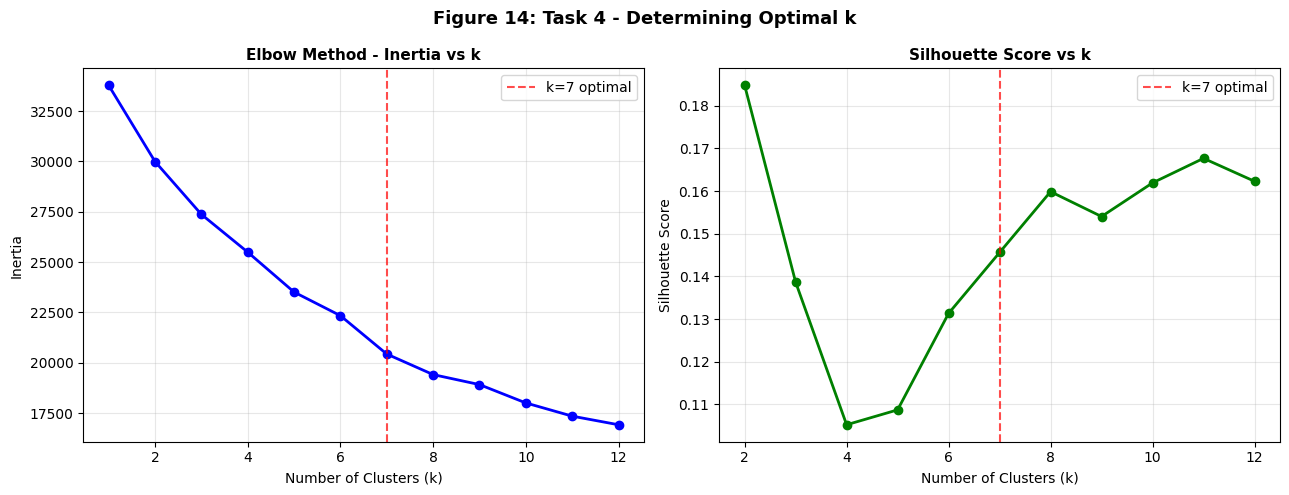

Saved: fig14_elbow_silhouette.png


In [33]:
# Figure 14 - Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.plot(range(1,13), inertias, 'b-o', ms=6, lw=2)
ax1.axvline(x=7, color='red', linestyle='--', alpha=0.7, label='k=7 optimal')
ax1.set_title('Elbow Method - Inertia vs k', fontsize=11, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)'); ax1.set_ylabel('Inertia')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(range(2,13), sil_scores, 'g-o', ms=6, lw=2)
ax2.axvline(x=7, color='red', linestyle='--', alpha=0.7, label='k=7 optimal')
ax2.set_title('Silhouette Score vs k', fontsize=11, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)'); ax2.set_ylabel('Silhouette Score')
ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Figure 14: Task 4 - Determining Optimal k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig14_elbow_silhouette.png")


In [34]:
# Apply K-Means with k=7
kmeans = KMeans(n_clusters=7, random_state=42, n_init=20, max_iter=500)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

# Map each cluster to majority true class
cluster_to_class = {}
for c in range(7):
    mask_c = cluster_labels == c
    if mask_c.sum() > 0:
        majority = mode(y.values[mask_c], keepdims=True).mode[0]
        cluster_to_class[c] = majority
mapped_preds = np.array([cluster_to_class[c] for c in cluster_labels])

# Evaluate
clust_accuracy = accuracy_score(y, mapped_preds)
sil_final      = silhouette_score(X_scaled, cluster_labels)
db_final       = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Clustering Accuracy   : {clust_accuracy*100:.2f}%")
print(f"Silhouette Score      : {sil_final:.4f}  (closer to 1.0 is better)")
print(f"Davies-Bouldin Index  : {db_final:.4f}  (lower is better)")
print()
print("Cluster to Class Mapping:")
for c, cls_idx in cluster_to_class.items():
    print(f"  Cluster {c}  ->  {class_names[cls_idx]}")

Clustering Accuracy   : 40.03%
Silhouette Score      : 0.1517  (closer to 1.0 is better)
Davies-Bouldin Index  : 1.8620  (lower is better)

Cluster to Class Mapping:
  Cluster 0  ->  Obesity_Type_I
  Cluster 1  ->  Obesity_Type_II
  Cluster 2  ->  Overweight_Level_I
  Cluster 3  ->  Obesity_Type_III
  Cluster 4  ->  Insufficient_Weight
  Cluster 5  ->  Obesity_Type_I
  Cluster 6  ->  Obesity_Type_II


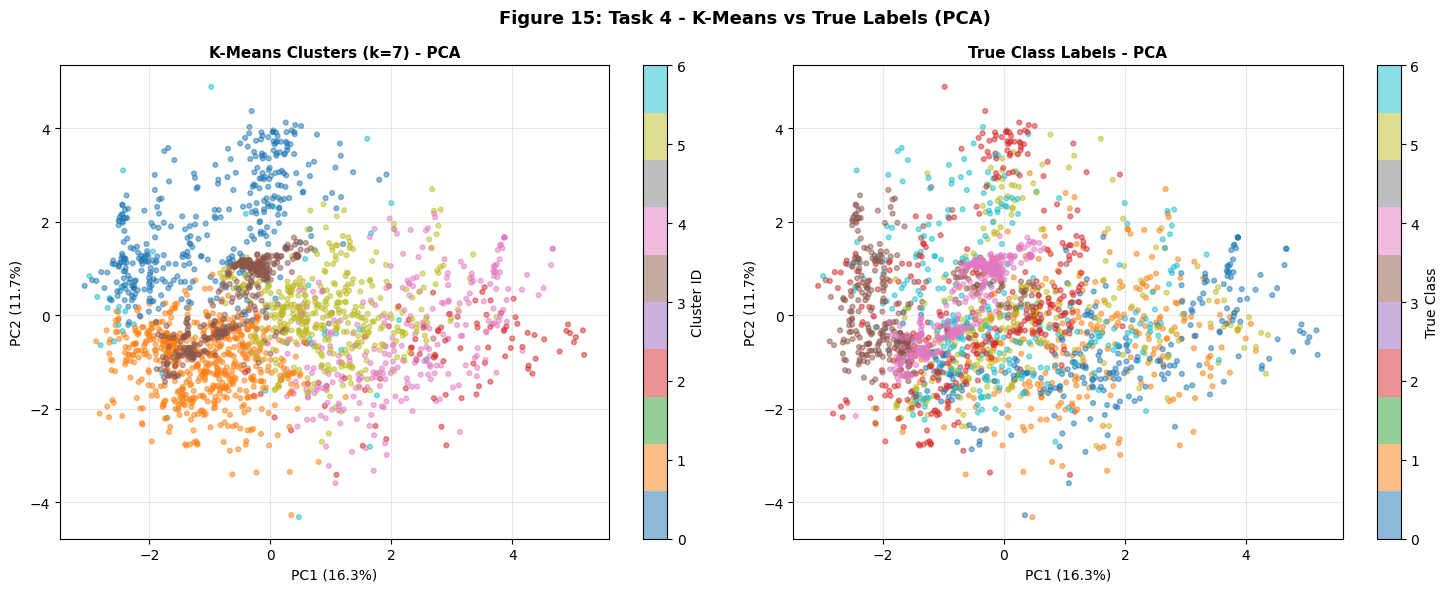

Saved: fig15_clustering_pca.png


In [35]:
# Figure 15 - PCA Scatter
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
sc1 = ax1.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='tab10', alpha=0.5, s=12)
ax1.set_title('K-Means Clusters (k=7) - PCA', fontsize=11, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc1, ax=ax1, label='Cluster ID'); ax1.grid(alpha=0.3)
sc2 = ax2.scatter(X_pca[:,0], X_pca[:,1], c=y.values, cmap='tab10', alpha=0.5, s=12)
ax2.set_title('True Class Labels - PCA', fontsize=11, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc2, ax=ax2, label='True Class'); ax2.grid(alpha=0.3)
plt.suptitle('Figure 15: Task 4 - K-Means vs True Labels (PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig15_clustering_pca.png")


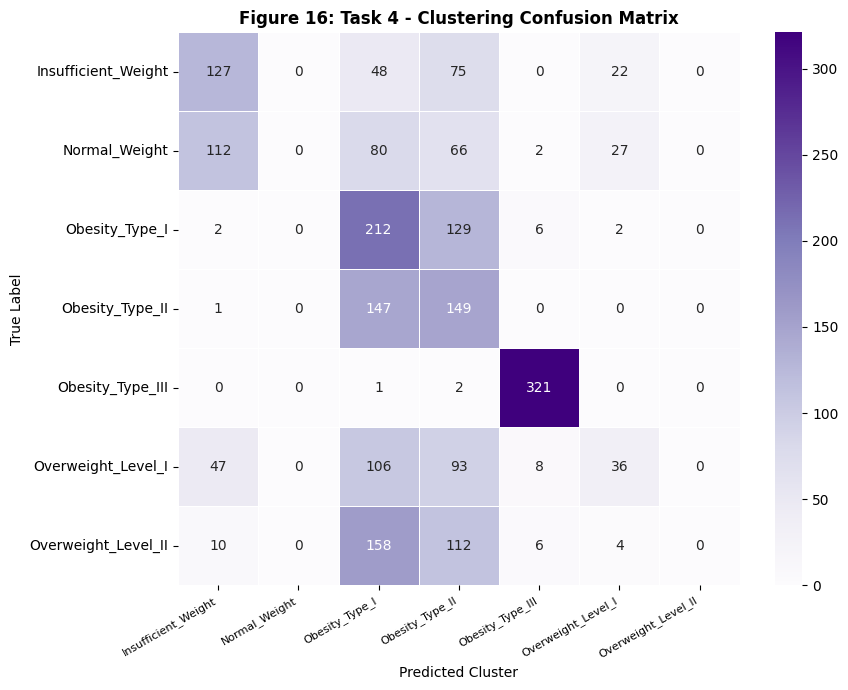

Saved: fig16_clustering_confusion.png


In [36]:
# Figure 16 - Clustering Confusion Matrix
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(confusion_matrix(y, mapped_preds), annot=True, fmt='d',
            cmap='Purples', xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.5)
ax.set_title('Figure 16: Task 4 - Clustering Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Cluster'); ax.set_ylabel('True Label')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig16_clustering_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig16_clustering_confusion.png")


## 8. Final Results Summary

In [38]:
summary = pd.DataFrame({
    'Task': ['MLP Model', 'Ensemble Model', 'CNN Model', 'K-Means Clustering'],
    
    'Model': [
        'MLP with 4 hidden layers',
        'Voting Classifier (RF + GB + SVM)',
        'CNN with 4 Conv1D layers',
        'K-Means (k=7)'
    ],
    
    'Accuracy': [
        f'{mlp_accuracy*100:.2f}%',
        f'{ens_accuracy*100:.2f}%',
        f'{cnn_accuracy*100:.2f}%',
        f'{clust_accuracy*100:.2f}%'
    ]
})

# Add simple comments for each model
best_acc = max(mlp_accuracy, ens_accuracy, cnn_accuracy)

notes = []

for acc, text in [
    (mlp_accuracy, 'Good neural network performance'),
    (ens_accuracy, 'Reliable ensemble result'),
    (cnn_accuracy, 'CNN worked reasonably well')
]:
    if acc == best_acc:
        notes.append('Best overall result')
    else:
        notes.append(text)

notes.append(f'Silhouette={sil_final:.3f}, DB={db_final:.3f}')

summary['Notes'] = notes

print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(summary.to_string(index=False))

print("=" * 60)
print("\nGraphs saved successfully.")
print("Dataset used: Obesity Levels Dataset from Kaggle")
print("\nProject completed successfully!")

FINAL PROJECT SUMMARY
              Task                             Model Accuracy                           Notes
         MLP Model          MLP with 4 hidden layers   94.09% Good neural network performance
    Ensemble Model Voting Classifier (RF + GB + SVM)   95.74%             Best overall result
         CNN Model          CNN with 4 Conv1D layers   88.18%      CNN worked reasonably well
K-Means Clustering                     K-Means (k=7)   40.03%      Silhouette=0.152, DB=1.862

Graphs saved successfully.
Dataset used: Obesity Levels Dataset from Kaggle

Project completed successfully!
